## 多实验结果对比绘图

- 在下面 `EXPERIMENTS` 里配置实验名和 `jsonl` 路径即可。
- 每个实验画两条线：`reward`（实线）与 `best_so_far`（虚线）。
- 支持 LLM trace（`iter/reward/best_so_far`）和 CMA-ES history（`generation/gen_max/best_so_far`）。


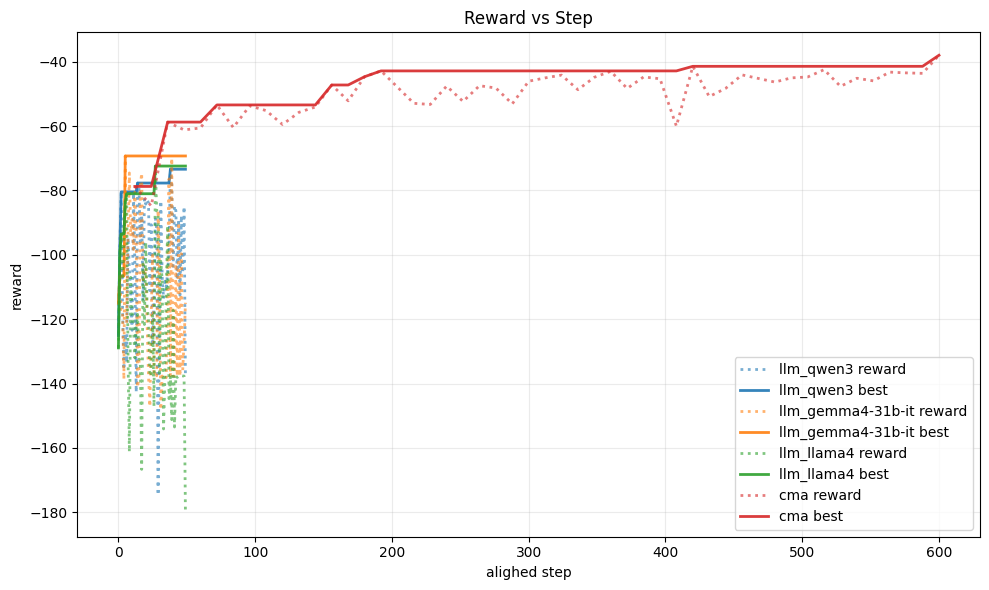

In [13]:
import json
from pathlib import Path

import matplotlib.pyplot as plt

# =====================
# 配置区：只改这里
# =====================
# x 轴缩放：用于“一个 step 内部会做多次 inference/评估”的算法
# 例如某算法每个 step 做 K 次 inference，你希望横轴用“inference 次数”对齐，则设 scale=K
GLOBAL_X_SCALE = 1.0

EXPERIMENTS = [
    {
        "name": "llm_qwen3",
        "path": "tmp/film_search_llm_qwen3_05061434/llm_trace.jsonl",
        # "x_scale": 1.0,  # 可选：覆盖 GLOBAL_X_SCALE
    },
    {
        "name": "llm_gemma4-31b-it",
        "path": "tmp/film_search_llm_gemma4-31b-it_05051634/llm_trace.jsonl",
    },
    {
        "name": "llm_llama4",
        "path": "tmp/film_search_llm_llama4_05061553/llm_trace.jsonl",
    },    
    {
        "name": "cma",
        "path": "tmp/film_search_cma/cma_history.jsonl",
        "x_scale": 12.0,  # 例：如果你想按 popsize 把 generation 换算成评估次数
    },
]

TITLE = "Reward vs Step"
FIGSIZE = (10, 6)
ALPHA_REWARD = 0.6
ALPHA_BEST = 0.9

# =====================
# 读/解析
# =====================

def _read_jsonl(path: str | Path) -> list[dict]:
    p = Path(path)
    if not p.exists():
        raise FileNotFoundError(f"找不到文件: {p.resolve()}")

    rows: list[dict] = []
    with p.open("r", encoding="utf-8") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#"):
                continue
            rows.append(json.loads(s))
    if not rows:
        raise ValueError(f"文件没有可解析的 jsonl 行: {p.resolve()}")
    return rows


def _infer_xy(rows: list[dict]) -> tuple[list[float], list[float], list[float]]:
    # x key
    if "iter" in rows[0]:
        xk = "iter"
    elif "generation" in rows[0]:
        xk = "generation"
    else:
        raise KeyError(f"无法推断 x 轴字段（期望 iter/generation），实际 keys={sorted(rows[0].keys())}")

    # reward key
    if "reward" in rows[0]:
        rk = "reward"
    elif "gen_max" in rows[0]:
        rk = "gen_max"
    else:
        raise KeyError(f"无法推断 reward 字段（期望 reward/gen_max），实际 keys={sorted(rows[0].keys())}")

    xs: list[float] = []
    rewards: list[float] = []
    bests: list[float] = []
    running_best: float | None = None

    for r in rows:
        x = r.get(xk)
        rew = r.get(rk)
        if x is None or rew is None:
            continue

        xs.append(float(x))
        rewards.append(float(rew))

        b = r.get("best_so_far")
        if b is None:
            if running_best is None:
                running_best = float(rew)
            else:
                running_best = max(running_best, float(rew))
            bests.append(running_best)
        else:
            bests.append(float(b))

    if not xs:
        raise ValueError("解析后没有有效数据点")

    return xs, rewards, bests


# =====================
# 画图
# =====================
plt.figure(figsize=FIGSIZE)

for exp in EXPERIMENTS:
    name = exp["name"]
    path = exp["path"]
    x_scale = float(exp.get("x_scale", GLOBAL_X_SCALE))

    rows = _read_jsonl(path)
    xs, rewards, bests = _infer_xy(rows)
    xs = [x * x_scale for x in xs]

    # 同一颜色：reward 实线，best 虚线
    (line,) = plt.plot(xs, rewards, linestyle=":", linewidth=2, alpha=ALPHA_REWARD, label=f"{name} reward")
    plt.plot(xs, bests, linestyle="-", linewidth=2, alpha=ALPHA_BEST, color=line.get_color(), label=f"{name} best")

plt.title(TITLE)
plt.xlabel("alighed step")
# plt.xlim(0, 60)
# plt.ylim(-180, -50)
plt.ylabel("reward")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()
